In [12]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc
from matplotlib.colors import to_rgb, rgb_to_hsv, hsv_to_rgb
from matplotlib.lines import Line2D


In [13]:
def dotted_style(i):
    base_styles = ['-', '--', '-.', ':']  # standard matplotlib styles
    if i < len(base_styles):
        return base_styles[i]
    else:
        # for i >= 4, generate sparser custom dash patterns
        dash_length = 1
        gap_length = 4 + (i-4)*2  # increase gap with i
        return (0, (dash_length, gap_length))

def vary_brightness(base_color, i, n, v_min=0.4, v_max=1.0):
    rgb = to_rgb(base_color)
    hsv = rgb_to_hsv(rgb)
    
    # interpolate brightness (value channel)
    t = i / (n - 1) if n > 1 else 0
    hsv[2] = v_min + (v_max - v_min) * t
    
    return hsv_to_rgb(hsv)

/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,
/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,
/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,
/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,
/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,
/tmp/ipykernel_49904/94302810.py:25: RuntimeWarning: divide by zero encountered in divide
  ax.plot(tpr, 1/fpr,


Text(0.5, 0.98, '600K vs. 10Mil')

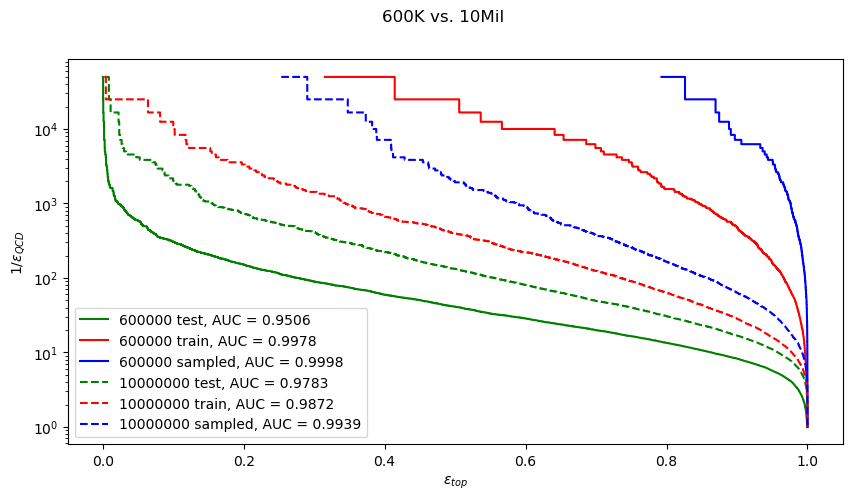

In [14]:
epochs = ["best"]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folders = ["JETCLASS_600000_warmup_cosine", "JETCLASS_10000000_cosine_restarts_50"]
n_jets = [600000, 10000000]

fig, ax = plt.subplots(figsize=(10, 5))
for k in range(len(folders)):
    for j in range(len(tags)):

        auc_scores = np.array([])
        ax.plot()

        for i in range(len(epochs)):
            scores = pd.read_csv(f"../output/evaluation/{folders[k]}/epoch_{epochs[i]}/all_scores.csv")

            scores = scores[scores["tag"] == tags[j]]

            fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

            roc_auc = auc(fpr, tpr)

            ax.plot(tpr, 1/fpr, 
                label = f"{n_jets[k]} {tags[j]}, AUC = {roc_auc:.4f}", 
                color = colors[j],
                linestyle = dotted_style(k))
            
            auc_scores = np.append(auc_scores, roc_auc)


    legend_elements = [
        Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
        for i in range(len(tags))
    ]

ax.legend()

ax.set_yscale("log")


ax.set_xlabel(r"$\epsilon_{top}$")
ax.set_ylabel(r"$1/\epsilon_{QCD}$")

fig.suptitle(f"600K vs. 10Mil")

    



/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/2657115495.py:24: RuntimeWarning: divide by

Text(0.5, 0.98, 'Model JETCLASS_600000_warmup_cosine')

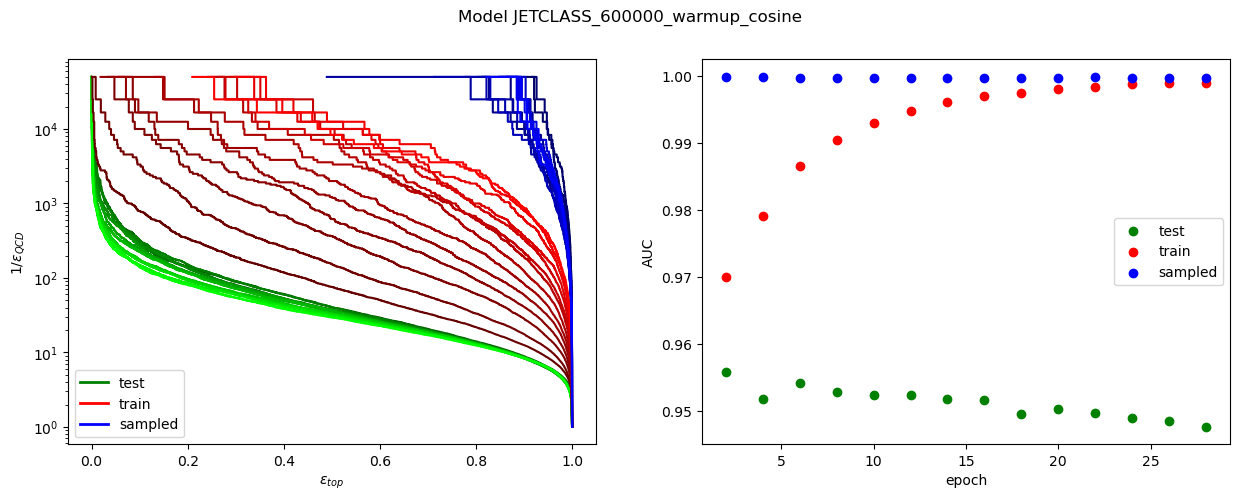

In [15]:
epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_600000_warmup_cosine"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/36172653.py:24: RuntimeWarning: divide by zero encountered 

Text(0.5, 0.98, 'Model JETCLASS_10000000_cosine_restarts_25')

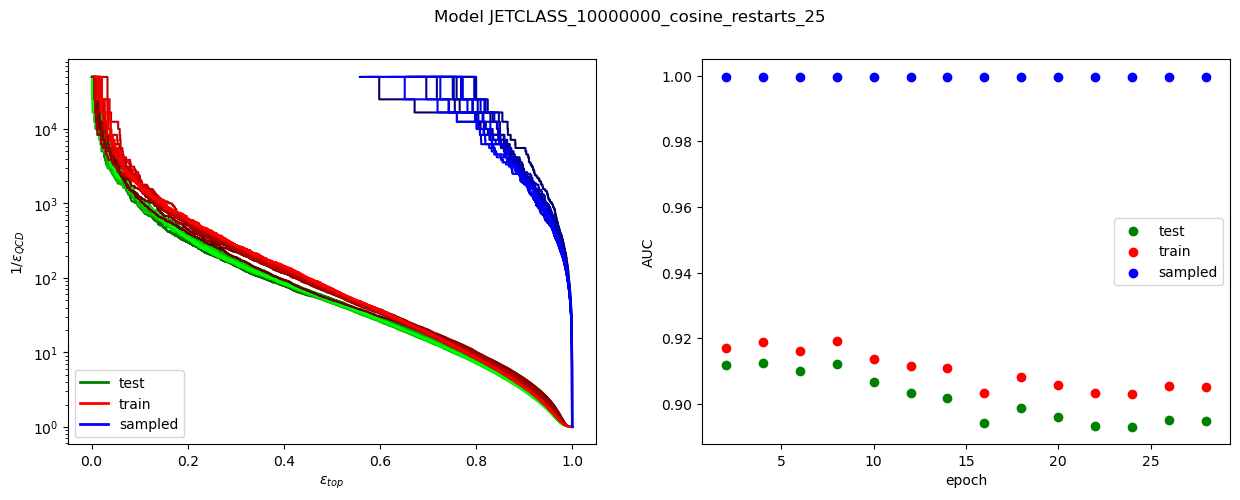

In [16]:
epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_10000000_cosine_restarts_25"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/966642830.py:24: RuntimeWarning: divide by zero enc

Text(0.5, 0.98, 'Model JETCLASS_10000000_cosine_restarts_25_const_50')

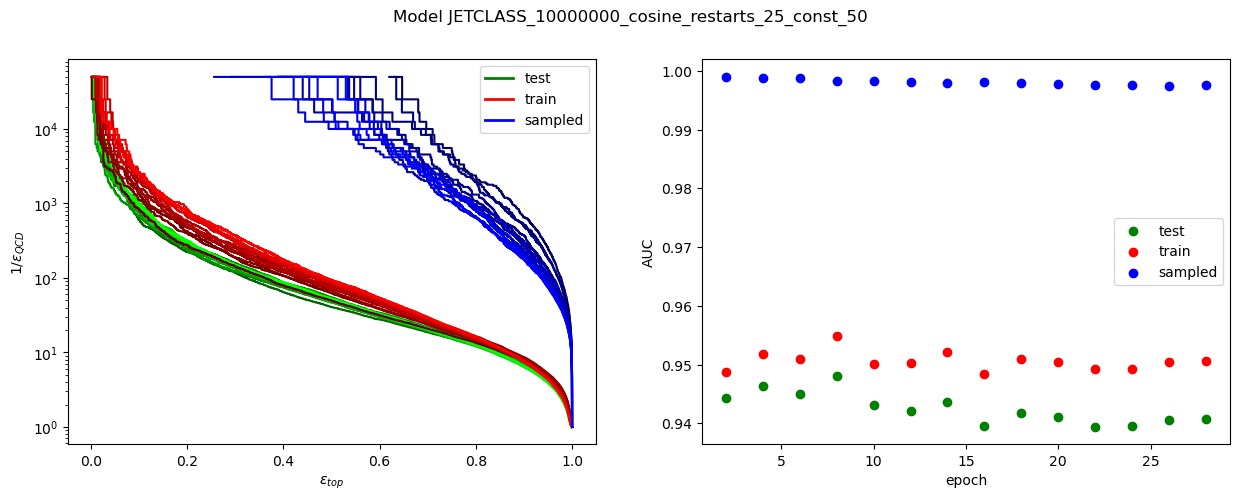

In [17]:
epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_10000000_cosine_restarts_25_const_50"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/4202988663.py:24: RuntimeWarning: divide by

Text(0.5, 0.98, 'Model JETCLASS_10000000_cosine_restarts_50')

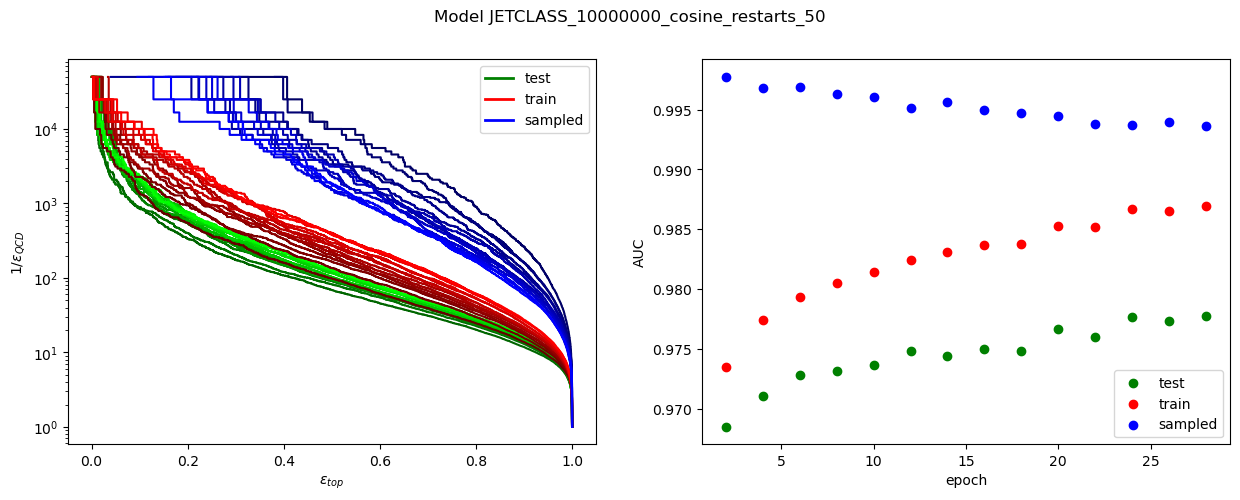

In [18]:
epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_10000000_cosine_restarts_50"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/718097091.py:24: RuntimeWarning: divide by zero enc

Text(0.5, 0.98, 'Model JETCLASS_10000000_cosine_restarts_128')

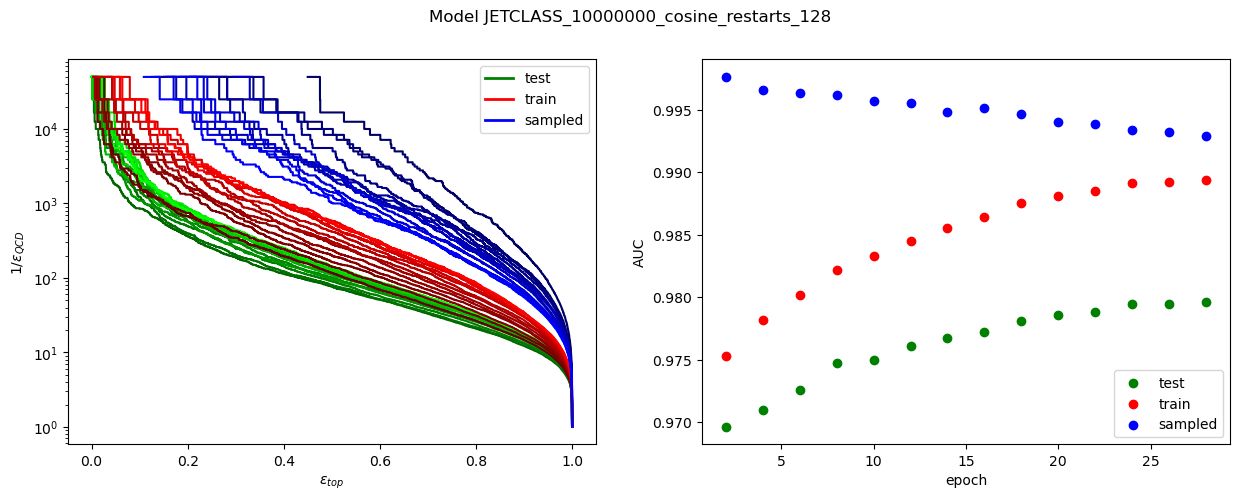

In [19]:
epochs = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_10000000_cosine_restarts_128"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,


/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/165681773.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,


Text(0.5, 0.98, 'Model JETCLASS_10000000_cosine_restarts_50_untrained')

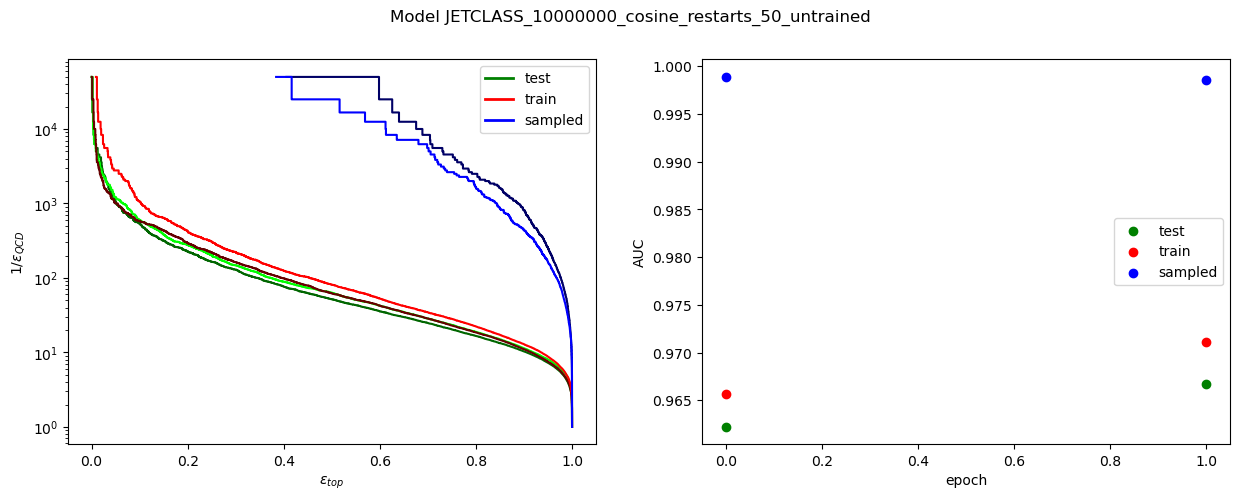

In [20]:
epochs = [0, 1]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_10000000_cosine_restarts_50_untrained"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")

    



/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,
/tmp/ipykernel_49904/374241406.py:24: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(tpr, 1/fpr,


Text(0.5, 0.98, 'Model JETCLASS_600000_cosine_restarts_50_untrained')

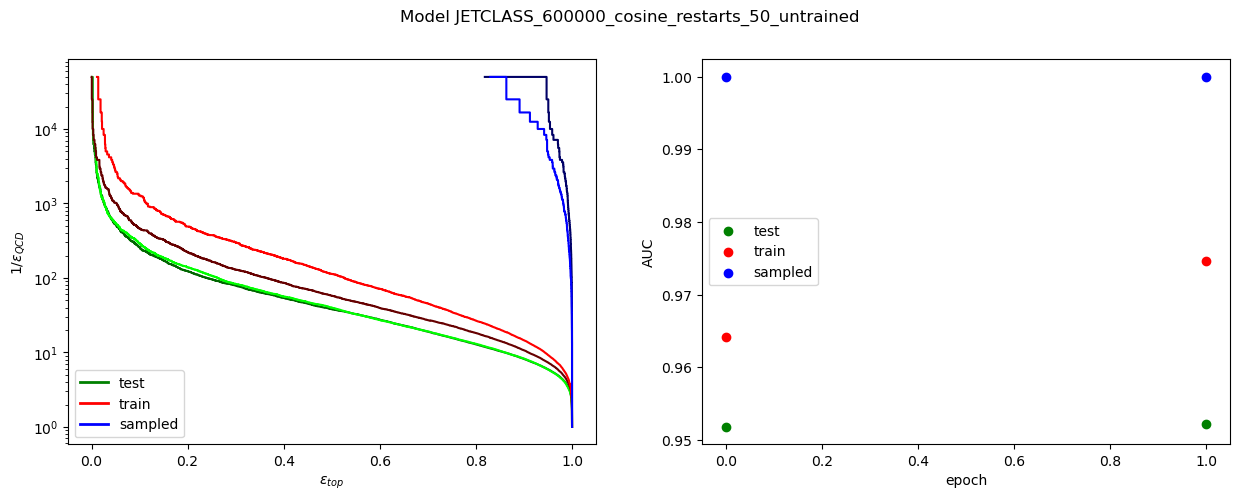

In [ ]:
epochs = [0, 1]

tags = ["test", "train", "sampled"]
colors = ["green", "red", "blue"]

folder = "JETCLASS_600000_cosine_restarts_50_untrained"

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for j in range(len(tags)):

    auc_scores = np.array([])
    ax[0].plot()

    for i in range(len(epochs)):
        scores = pd.read_csv(f"../output/evaluation/{folder}/epoch_{epochs[i]}/all_scores.csv")

        scores = scores[scores["tag"] == tags[j]]

        fpr, tpr, thresholds = roc_curve(scores["label"].values, scores["score"].values)

        roc_auc = auc(fpr, tpr)

        ax[0].plot(tpr, 1/fpr, 
            #label = f"{tags[j]} epoch {epochs[i]}, AUC = {roc_auc:.4f}", 
            color = vary_brightness(colors[j], i, len(epochs)))
        
        auc_scores = np.append(auc_scores, roc_auc)

    ax[1].scatter(epochs, auc_scores, color = colors[j], label = f"{tags[j]}")

legend_elements = [
    Line2D([0], [0], color=colors[i], lw=2, label=f"{tags[i]}")
    for i in range(len(tags))
]

ax[0].legend(handles = legend_elements)

ax[0].set_yscale("log")


ax[0].set_xlabel(r"$\epsilon_{top}$")
ax[0].set_ylabel(r"$1/\epsilon_{QCD}$")

ax[1].set_xlabel("epoch")
ax[1].set_ylabel("AUC")

ax[1].legend()

fig.suptitle(f"Model {folder}")